In [1]:
library(limma)
library(Biobase)
library(dplyr)
library(ggplot2)
library(magrittr)
library(ggrepel)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.



Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following

Expression Set object

In [2]:
data <- read.csv("extdata/all_emci_metab_hmdb_lilikoi.csv", header=TRUE)
name_map <- read.csv("extdata/name_map.csv",header=TRUE)

In [3]:
for (i in 1:nrow(name_map)){
    number=substr(name_map$HMDB[i], nchar(name_map$HMDB[i]) - 5 + 1, nchar(name_map$HMDB[i]))
    hmdb_name=paste("HMDB",number,sep="")
    name_map$HMDB[i]=hmdb_name
}
name_map

Query,Match,HMDB,PubChem,KEGG,SMILES,Comment
<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>
HMDB0013438,"PC(o-18:2(9Z,12Z)/24:0)",HMDB13438,53481741,NA,CCCCCCCCCCCCCCCCCCCCCCCC(=O)O[C@H](COCCCCCCCC/C=C\C/C=C\CCCCC)COP(=O)([O-])OCC[N+](C)(C)C,1
HMDB0010169,SM(d18:1/16:0),HMDB10169,5283590,C00550,CCCCCCCCCCCCCCCC(=O)N[C@@H](COP(=O)(O)OCC[N+](C)(C)C)[C@@H](/C=C/CCCCCCCCCCCCC)O,1
HMDB0007887,PC(14:0/22:1(13Z)),HMDB07887,53478609,C00157,CCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCCCCCCCCC/C=C\CCCCCCCC,1
HMDB0013449,"PC(o-22:0/22:3(10Z,13Z,16Z))",HMDB13449,53481753,NA,CCCCCCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCCCCCC/C=C\C/C=C\C/C=C\CCCCC,1
HMDB0013458,"PC(o-24:0/18:3(6Z,9Z,12Z))",HMDB13458,53481771,NA,CCCCCCCCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCC/C=C\C/C=C\C/C=C\CCCCC,1
HMDB0013429,"PC(o-18:1(9Z)/18:2(9Z,12Z))",HMDB13429,6443159,NA,CCCCCCCC/C=C\CCCCCCCCOC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCCCCC/C=C\C/C=C\CCCCC,1
HMDB0013412,PC(o-16:1(9Z)/18:0),HMDB13412,53481707,NA,CCCCCCCCCCCCCCCCCC(=O)O[C@H](COCCCCCCCC/C=C\CCCCCC)COP(=O)([O-])OCC[N+](C)(C)C,1
HMDB0013414,PC(o-16:1(9Z)/20:0),HMDB13414,53481711,NA,CCCCCCCCCCCCCCCCCCCC(=O)O[C@H](COCCCCCCCC/C=C\CCCCCC)COP(=O)([O-])OCC[N+](C)(C)C,1
HMDB0011151,"PC(O-16:0/18:2(9Z,12Z))",HMDB11151,6443157,NA,CCCCCCCCCCCCCCCCOC[C@H](COP(=O)([O-])OCC[N+](C)(C)C)OC(=O)CCCCCCC/C=C\C/C=C\CCCCC,1


In [4]:
data_1 = data[,c(-1,-2)]

In [5]:
rownames(data_1) = data$PID #rownames(data)

In [6]:
data_2 = t(data_1)

In [7]:
data_2

,002_S_2043,002_S_2073,002_S_4237,002_S_4447,002_S_4473,003_S_2374,005_S_2390,005_S_4168,005_S_4185,007_S_2058,⋯,141_S_2210,141_S_4160,141_S_4232,141_S_4438,153_S_2109,153_S_4297,153_S_4621,941_S_2060,941_S_4036,941_S_4420
HMDB00619,-0.879254023,-0.73989079,-0.47021254,1.71355423,1.69587160,2.03803825,-0.25309351,-0.21213723,-0.83877645,0.170612791,⋯,-0.70975539,-0.46148190,-0.44229534,2.72170924,0.393135149,-0.38966976,0.07132425,1.47610920,1.92007088,0.99012716
HMDB00518,-0.187552075,-1.91930042,-0.24595825,0.78147024,0.95790709,1.28120195,-0.08788665,-0.56198659,-1.12873731,0.576786096,⋯,-1.91930042,0.36954633,0.05040447,1.43308753,0.271000781,-1.27746835,-0.19334429,0.92888860,1.11035056,0.86075216
HMDB00626,0.752953398,0.26471396,-0.19755277,-0.07764682,-0.75617773,-0.91604215,0.10015465,-0.57005488,-0.57698428,-2.277127288,⋯,-0.07053428,1.65794293,0.26982401,0.43775217,-1.244202264,0.43112864,0.06614263,-0.42351809,0.94736062,-0.50370367
HMDB00138,0.287366768,-0.13719641,-0.28363903,0.77153065,0.05948350,0.04903622,-0.11642227,-0.66016879,-0.66746683,-0.649552900,⋯,-1.51456996,0.60926957,1.56322283,0.19066767,-0.172717174,1.50715674,-0.01631501,0.66881608,0.65242559,0.30538909
HMDB02579,0.368879492,-0.28091724,-1.02422483,-0.08503491,0.12395451,-0.08939923,0.79578026,0.04902433,-0.33555874,0.113819601,⋯,-2.64234867,0.76782325,1.46474833,0.09228561,-0.176510425,1.35500870,0.07433938,0.09190777,-0.34409206,0.10740244
HMDB00631,0.898702226,0.91326370,-0.57586546,-0.21645786,-0.75589223,-1.39386984,1.10758805,-0.33738851,-0.51261758,-3.000000000,⋯,-1.22045163,1.34548365,1.51954174,-0.39677172,-1.307859138,1.49057503,0.25080680,-0.60269170,0.42643891,-1.21779606
HMDB00698,-0.186143086,1.40128867,-0.31732699,-0.41905558,0.66297811,-0.25633294,1.23271089,-0.47339823,0.28135821,-1.278528041,⋯,-0.67868140,1.42439193,0.17962962,-1.27852804,-0.277143236,1.79634307,-0.26472052,-0.37060997,0.31039444,-1.27852804
HMDB00708,1.344337926,-1.31044838,-0.15177014,0.07319015,0.06781828,-0.46951728,0.51994708,0.75157444,-0.20996363,1.738388427,⋯,-2.18594630,-0.13115852,0.65777375,0.18356296,0.370511442,0.32085350,0.16736242,0.65086782,-0.92000585,-0.37011646
HMDB00036,0.567560620,0.28359746,0.72161975,0.61592201,-0.45639422,0.37807266,-1.15785960,-1.15785960,-0.38933542,-0.526796234,⋯,-1.15785960,0.10131302,1.43367282,1.52979146,-1.157859601,1.62553124,-0.02862173,0.17996812,1.16325659,0.34976031
HMDB00951,0.991313352,-0.03097047,0.08679076,0.08679076,-0.54419428,-0.20726922,-0.78240345,-1.15197019,-0.10042343,-0.001201593,⋯,-1.83345009,0.02840445,1.72890575,0.21639209,-1.488773137,1.46674889,-0.13119255,0.28558917,0.04049461,0.33645040


In [8]:
subtype_info<-read.csv("extdata/cn_emci_lmci_ad_clin_pseudotime.csv",header=TRUE)
table(subtype_info$SNF)
name_emci1<-subtype_info$PID[which(subtype_info$SNF=="emcisubtype1")]
name_emci2<-subtype_info$PID[which(subtype_info$SNF=="emcisubtype2")]


          AD           CN emcisubtype1 emcisubtype2 lmcisubtype1 lmcisubtype2 
         339          534          108           93           85          115 

In [9]:
# # ###### subset clusters for c=2 SNF MRNA + METAB
data_subset_1=as.matrix(data_2[,name_emci1])
data_subset_2=as.matrix(data_2[,name_emci2])
dim(data_subset_1)
dim(data_subset_2)

data_subset = cbind(data_subset_1,data_subset_2)

dataset <- ExpressionSet(assayData=as.matrix(data_subset))

sub1 = dim(data_subset_1)[2]
sub2 = dim(data_subset_2)[2]
design = cbind(c(c(rep(1, sub1)),c(rep(0, sub2))),c(c(rep(0, sub1)),c(rep(1, sub2))))
colnames(design) <- c("subset1","subset2")

[1] 172 108

[1] 172  93

In [10]:
fit <- lmFit(data_subset, design)
cont.matrix <- makeContrasts(contrasts = "subset2-subset1", levels=design) # subset1 as the control group
fit2 <- contrasts.fit(fit, cont.matrix)
fit2 <- eBayes(fit2, trend=FALSE)

In [11]:
limma_result_fit <- topTable(fit2, n=Inf)
limma_result_fit$metab_symbol <- row.names(limma_result_fit)
limma_result_fit

,logFC,AveExpr,t,P.Value,adj.P.Val,B,metab_symbol
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
HMDB13438,1.4469477,-0.266677736,13.519029,1.962060e-30,3.374742e-28,58.48563,HMDB13438
HMDB10169,1.2420999,0.078109007,12.163036,3.690091e-26,3.173478e-24,48.76255,HMDB10169
HMDB07887,1.2572775,0.312438132,11.498974,4.316661e-24,2.468443e-22,44.05952,HMDB07887
HMDB13449,1.1106891,-0.552840275,11.458980,5.740566e-24,2.468443e-22,43.77802,HMDB13449
HMDB13458,1.2949338,-0.235643066,11.420743,7.537578e-24,2.592927e-22,43.50911,HMDB13458
HMDB13429,1.1558755,0.230221661,10.944442,2.201422e-22,6.310742e-21,40.17779,HMDB13429
HMDB13412,1.1086056,0.345274617,10.654693,1.683709e-21,4.137113e-20,38.16988,HMDB13412
HMDB13414,1.1644835,-0.209233660,10.509504,4.639634e-21,9.388706e-20,37.16968,HMDB13414
HMDB11151,1.0813483,0.251004910,10.501295,4.912695e-21,9.388706e-20,37.11326,HMDB11151


In [12]:
#### plot volcano

fold_cutoff = 0.3

limma_result_fit$diffexpressed <- "NO"
# if log2Foldchange > 0.5 and pvalue < 0.05, set as "UP" 
limma_result_fit$diffexpressed[limma_result_fit$logFC > fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "UP"
# if log2Foldchange < -0.5 and pvalue < 0.05, set as "DOWN"
limma_result_fit$diffexpressed[limma_result_fit$logFC < -fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "DOWN"

limma_result_fit$delabel <- NA

for (i in 1:nrow(limma_result_fit)){
    if (limma_result_fit$diffexpressed[i] != "NO"){
        hmdb_name=limma_result_fit$metab_symbol[i]
        if (hmdb_name %in% name_map$HMDB){
            idx=which(name_map$HMDB==hmdb_name)
            real_name=name_map$Match[idx]
            limma_result_fit$delabel[i]=real_name
        }
    }
}


Warning message:
“Removed 74 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 92 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


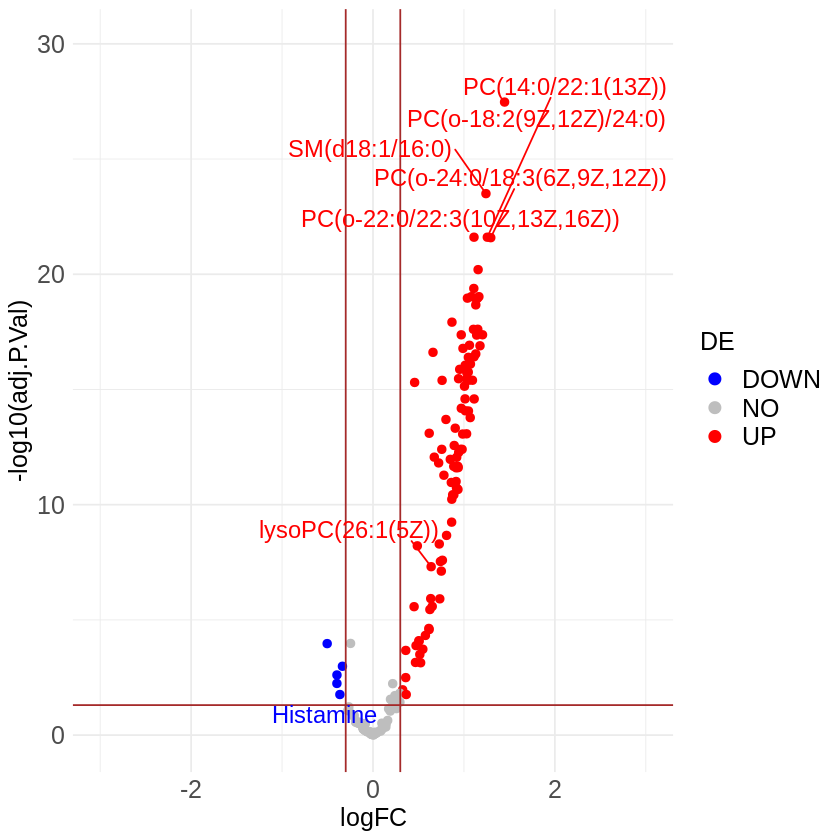

In [13]:
ggplot(data=limma_result_fit, aes(x=logFC, y=-log10(adj.P.Val),col=diffexpressed)) +
        geom_point(size=2) +
        theme_minimal() +
        scale_color_manual(breaks=c("DOWN","NO","UP"),values=c("blue", "grey", "red")) +
        guides(color=guide_legend(title = "DE",override.aes = list(size = 3))) +
        geom_vline(xintercept=c(-fold_cutoff, fold_cutoff), col="brown") +
        geom_hline(yintercept=-log10(0.05), col="brown") + 
        xlim(-3, 3) +ylim(-0.1,30) +
        theme(axis.title = element_text(size = 15),axis.text=element_text(size=15),legend.title=element_text(size=15),legend.text=element_text(size=15))+
        geom_text_repel(aes(label=delabel),size=5,max.overlaps=5,force=20)

#ggsave("figs/RP_2d.png",dpi=600)    

In [14]:
limma_DE = limma_result_fit[which(limma_result_fit$diffexpressed != "NO"), ]

In [15]:
limma_DE

,logFC,AveExpr,t,P.Value,adj.P.Val,B,metab_symbol,diffexpressed,delabel
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
HMDB13438,1.4469477,-0.266677736,13.519029,1.962060e-30,3.374742e-28,58.48563,HMDB13438,UP,"PC(o-18:2(9Z,12Z)/24:0)"
HMDB10169,1.2420999,0.078109007,12.163036,3.690091e-26,3.173478e-24,48.76255,HMDB10169,UP,SM(d18:1/16:0)
HMDB07887,1.2572775,0.312438132,11.498974,4.316661e-24,2.468443e-22,44.05952,HMDB07887,UP,PC(14:0/22:1(13Z))
HMDB13449,1.1106891,-0.552840275,11.458980,5.740566e-24,2.468443e-22,43.77802,HMDB13449,UP,"PC(o-22:0/22:3(10Z,13Z,16Z))"
HMDB13458,1.2949338,-0.235643066,11.420743,7.537578e-24,2.592927e-22,43.50911,HMDB13458,UP,"PC(o-24:0/18:3(6Z,9Z,12Z))"
HMDB13429,1.1558755,0.230221661,10.944442,2.201422e-22,6.310742e-21,40.17779,HMDB13429,UP,"PC(o-18:1(9Z)/18:2(9Z,12Z))"
HMDB13412,1.1086056,0.345274617,10.654693,1.683709e-21,4.137113e-20,38.16988,HMDB13412,UP,PC(o-16:1(9Z)/18:0)
HMDB13414,1.1644835,-0.209233660,10.509504,4.639634e-21,9.388706e-20,37.16968,HMDB13414,UP,PC(o-16:1(9Z)/20:0)
HMDB11151,1.0813483,0.251004910,10.501295,4.912695e-21,9.388706e-20,37.11326,HMDB11151,UP,"PC(O-16:0/18:2(9Z,12Z))"


In [16]:
rownames(limma_DE)

[1] "HMDB13438"   "HMDB10169"   "HMDB07887"   "HMDB13449"   "HMDB13458"  
  [6] "HMDB13429"   "HMDB13412"   "HMDB13414"   "HMDB11151"   "HMDB11697"  
 [11] "HMDB08183"   "HMDB13411"   "HMDB13466"   "HMDB13431"   "HMDB08192"  
 [16] "HMDB13464"   "HMDB13410"   "HMDB13434"   "HMDB12107"   "HMDB13448"  
 [21] "HMDB13453"   "HMDB13444"   "HMDB13124"   "HMDB13433"   "HMDB13404"  
 [26] "HMDB08163"   "HMDB13341"   "HMDB13409"   "HMDB13462"   "HMDB07867"  
 [31] "HMDB13417"   "HMDB13467"   "HMDB13405"   "HMDB00756"   "HMDB13418"  
 [36] "HMDB13413"   "HMDB13437"   "HMDB13439"   "HMDB13446"   "HMDB07965"  
 [41] "HMDB13469"   "HMDB07981"   "HMDB00564"   "HMDB13432"   "HMDB08607"  
 [46] "HMDB29221"   "HMDB08798"   "HMDB11698"   "HMDB08308"   "HMDB08606"  
 [51] "HMDB08538"   "HMDB13463"   "HMDB07911"   "HMDB13408"   "HMDB13442"  
 [56] "HMDB08232"   "HMDB13125"   "HMDB01348"   "HMDB13451"   "HMDB08070"  
 [61] "HMDB07985"   "HMDB08537"   "HMDB08539"   "HMDB10405"   "HMDB13461"  
 [66] "HMDB13415"   "HMDB13422"   "HMDB13456"   "HMDB08271"   "HMDB13435"  
 [71] "HMDB08657"   "HMDB08522"   "HMDB08055"   "HMDB13450"   "HMDB02014"  
 [76] "HMDB08029"   "HMDB07898"   "HMDB12101"   "HMDB29220"   "HMDB13420"  
 [81] "HMDB29205"   "HMDB08536"   "HMDB07983"   "HMDB29206"   "HMDB07984"  
 [86] "HMDB10383"   "HMDB10385"   "HMDB10393"   "HMDB08688"   "HMDB08751"  
 [91] "HMDB00510"   "HMDB10384"   "HMDB13465"   "HMDB13129"   "HMDB10386"  
 [96] "HMDB12108"   "HMDB08431"   "HMDB00148"   "HMDB00162"   "HMDB62319"  
[101] "HMDB06469.1" "HMDB10382"   "HMDB00870"   "HMDB00123"

In [20]:
top10=limma_DE[order(limma_DE$adj.P.Val),][1:10,]
top10

,logFC,AveExpr,t,P.Value,adj.P.Val,B,metab_symbol,diffexpressed,delabel
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
HMDB13438,1.446948,-0.266677736,13.51903,1.962060e-30,3.374742e-28,58.48563,HMDB13438,UP,"PC(o-18:2(9Z,12Z)/24:0)"
HMDB10169,1.242100,0.078109007,12.16304,3.690091e-26,3.173478e-24,48.76255,HMDB10169,UP,SM(d18:1/16:0)
HMDB07887,1.257277,0.312438132,11.49897,4.316661e-24,2.468443e-22,44.05952,HMDB07887,UP,PC(14:0/22:1(13Z))
HMDB13449,1.110689,-0.552840275,11.45898,5.740566e-24,2.468443e-22,43.77802,HMDB13449,UP,"PC(o-22:0/22:3(10Z,13Z,16Z))"
HMDB13458,1.294934,-0.235643066,11.42074,7.537578e-24,2.592927e-22,43.50911,HMDB13458,UP,"PC(o-24:0/18:3(6Z,9Z,12Z))"
HMDB13429,1.155876,0.230221661,10.94444,2.201422e-22,6.310742e-21,40.17779,HMDB13429,UP,"PC(o-18:1(9Z)/18:2(9Z,12Z))"
HMDB13412,1.108606,0.345274617,10.65469,1.683709e-21,4.137113e-20,38.16988,HMDB13412,UP,PC(o-16:1(9Z)/18:0)
HMDB13414,1.164483,-0.209233660,10.50950,4.639634e-21,9.388706e-20,37.16968,HMDB13414,UP,PC(o-16:1(9Z)/20:0)
HMDB11151,1.081348,0.251004910,10.50130,4.912695e-21,9.388706e-20,37.11326,HMDB11151,UP,"PC(O-16:0/18:2(9Z,12Z))"


In [18]:
#write.csv(limma_DE,"DE_results/RP_DEmetab_EMCI.csv")